# Tidy-up: real-data tests

Each section compares a **proposed change** against your **current code**, on your
**real cube / catalog / background** — not synthetic data. The proposed function
is defined *inline* in the cell so you can run it now, before editing the package.

Order:
0. Setup (load one real Stage-2 product + cube)
1. Bootstrap: merged+sliced vs your two-loop (equivalence + speedup)
2. Background smoother: vectorized vs current (agreement + speedup)
3. `rest_delta` sweep on real centroids
4. `cont_bounds`: current vs line-safe on real centroids
5. SHMR / Rvir on your real catalog masses
6. Forward-model an intrinsic width on a real stacked bin

> Adjust the package name (`utils_lya_halo`) and the galaxy-FITS path in Cell 0
> if yours differ.

## 0. Setup — load a real product and build the cube once

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace
import time

from utils_lya_halo import (PipelineConfig, run_measure, run_extract, run_stack, measure,
                            plotting, analysis, multicat, selection, core, stack)
from utils_lya_halo.io import read_galaxy_fits, apply_finite_cut
from run_config import cfg

bin_mode='virial'

cfg = replace(cfg, 
    catalog="MOSDEF",
    field="BOTH",
    bin_mode=bin_mode,
    flux_unit="L_kpc2",           # 'raw' | 'flux_arcsec2' | 'L_fiber' | 'L_kpc2'
    bins=[0, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0],
    #bins=[0, 10, 20, 50, 100, 200, 500, 1000, 2000],
    catalog_path="catalogs/lya_halo_catalog_cuts/ALL_haoiii_sn5_mosdef_catalog.txt",
    rest_wave_min=1100,
    rest_wave_max=1400,
    n_bootstrap = 1000)

# load and cut your mega-product as normal
if (bin_mode.lower() == 'virial'):
    product1 = read_galaxy_fits('./outputs/galaxy_catc1488c_b8_8c91de_AEGIS_MOSDEF_virial_biweight_image_bg57-63.fits')
    product2 = read_galaxy_fits('./outputs/galaxy_catc1488c_b8_8c91de_COSMOS_MOSDEF_virial_biweight_image_bg57-63.fits')
elif (bin_mode.lower() == 'kpc'):
    product1 = read_galaxy_fits('./outputs/galaxy_catc1488c_b8_87bd55_AEGIS_MOSDEF_kpc_biweight_image_bg57-63.fits')
    product2 = read_galaxy_fits('./outputs/galaxy_catc1488c_b8_87bd55_COSMOS_MOSDEF_kpc_biweight_image_bg57-63.fits')
else:
    print('Wrong input or \'other\' not yet implemented')

product1 = apply_finite_cut(product1, cfg.cut_radial_bin, cfg.min_good_wave)
product2 = apply_finite_cut(product2, cfg.cut_radial_bin, cfg.min_good_wave)

# combine into one product -- tags each galaxy with its source in column "SUBSET"
prod = multicat.combine_products(
    {"cat1": product1, "cat2": product2},
    label_col="SUBSET")

stacks = run_stack(cfg, keep_cube=True, verbose=True)

cube  = np.asarray(stacks["cube_flux"], float)   # (ngal, nrad, nwave_rest)
ecube = np.asarray(stacks["cube_err"],  float)
wave  = np.asarray(stacks["rest_wave"], float)
ngal, nrad, nwave = cube.shape
print(f"cube = {cube.shape}  rest grid {wave[0]:.0f}-{wave[-1]:.0f} A @ {cfg.rest_delta} A")
print(f"line_window={list(cfg.line_window)}  cont_bounds={cfg.cont_bounds}  "
      f"centroid={cfg.centroid_method}  stack={cfg.measure_stack_method}")

Finite-spectrum cut (bin 7, > 100 px): kept 230 / 248 galaxies
Finite-spectrum cut (bin 7, > 100 px): kept 276 / 280 galaxies
combined 2 products -> 506 galaxies (origin in column 'SUBSET')


FileNotFoundError: Neither AEGIS nor COSMOS galaxy FITS found in ./outputs for catalog MOSDEF.

## 1. Bootstrap — merged + window-sliced vs your two-loop

Your `measure_all_bins` runs `bootstrap_measurements` (centroids) and
`bootstrap_stack_error` (per-pixel error) as **two** 1000-draw loops, each
re-stacking the **full** rest grid. Both use `default_rng(seed)` with the same
per-draw `idx`, so a **single merged loop** on the **sliced** window reproduces
both *exactly* while doing far less work.

The merged function below calls your **real** `stack_galaxies` and
`measure_centroid`, so this is a true apples-to-apples equivalence test.

In [2]:
from utils_lya_halo.measure import (stack_galaxies, measure_centroid,
                                        bootstrap_measurements, bootstrap_stack_error)

def bootstrap_merged_sliced(flux_rf, err_rf, wave, nboot, *, stack_method,
                            line_window, cont_bounds, lya_center,
                            centroid_method, clip_negative, cont_method, cont_order,
                            seed=1, pad=2.0):
    """One loop -> centroid summary AND per-pixel stack error, on a sliced grid."""
    flux_rf = np.asarray(flux_rf, float)
    err_rf  = np.asarray(err_rf, float) if err_rf is not None else None
    wave    = np.asarray(wave, float)
    ngal, nrad, _ = flux_rf.shape

    lo = min(cont_bounds[0][0], line_window[0]) - pad
    hi = max(cont_bounds[1][1], line_window[1]) + pad
    sel = (wave >= lo) & (wave <= hi)
    wv  = wave[sel]
    fcube = flux_rf[:, :, sel]
    ecube = err_rf[:, :, sel] if err_rf is not None else None

    rng = np.random.default_rng(seed)
    cV    = np.full((nboot, nrad), np.nan)
    draws = np.empty((nboot, nrad, wv.size), np.float64)
    for b in range(nboot):
        idx = rng.integers(0, ngal, ngal)
        stack, _ = stack_galaxies(fcube[idx],
                                  ecube[idx] if ecube is not None else None,
                                  method=stack_method)
        draws[b] = stack
        for rb in range(nrad):
            res = measure_centroid(wv, stack[rb], method=centroid_method,
                                   clip_negative=clip_negative,
                                   bounds=tuple(line_window), cont_bounds=cont_bounds,
                                   lya_center=lya_center, cont_method=cont_method,
                                   cont_order=cont_order)
            cV[b, rb] = res["centroid_vel_kms"] if res["success"] else np.nan
    return {
        "centroid_v_med": np.nanmedian(cV, axis=0),
        "centroid_v_lo":  np.nanpercentile(cV, 16, axis=0),
        "centroid_v_hi":  np.nanpercentile(cV, 84, axis=0),
        "stack_err":      0.5*(np.nanpercentile(draws, 84, axis=0)
                               - np.nanpercentile(draws, 16, axis=0)),
        "sliced_wave":    wv,
    }

NB = 300          # keep modest for the timing test; use cfg.n_bootstrap for real
sm = cfg.measure_stack_method
kw = dict(stack_method=sm, line_window=list(cfg.line_window),
          cont_bounds=cfg.cont_bounds, lya_center=cfg.LYA_REST,
          centroid_method=cfg.centroid_method, clip_negative=cfg.clip_negative,
          cont_method=cfg.cont_method, cont_order=cfg.cont_order)

print('START')
t0 = time.perf_counter()
merged = bootstrap_merged_sliced(cube, ecube, wave, NB, seed=1, **kw)
t_merged = time.perf_counter() - t0
print('Merged done!')

t0 = time.perf_counter()
old_c = bootstrap_measurements(cube, ecube, wave, nboot=NB,
        bounds=tuple(cfg.line_window), cont_bounds=cfg.cont_bounds,
        lya_center=cfg.LYA_REST, stack_method=sm, cont_method=cfg.cont_method,
        cont_order=cfg.cont_order, centroid_method=cfg.centroid_method,
        clip_negative=cfg.clip_negative, compute_side_ratio=False, seed=1, verbose=False)
old_e = bootstrap_stack_error(cube, ecube, nboot=NB, stack_method=sm, seed=1, verbose=False)
t_old = time.perf_counter() - t0
print('Old done!')

print("centroid_v_med  merged:", np.round(merged['centroid_v_med'], 1))
print("centroid_v_med  old   :", np.round(old_c['centroid_v_med'], 1))
print("max |Δcentroid| =", np.nanmax(np.abs(merged['centroid_v_med']-old_c['centroid_v_med'])), "km/s")
sel = (wave >= merged['sliced_wave'][0]) & (wave <= merged['sliced_wave'][-1])
print("max |Δstack_err| (sliced window) =",
      np.nanmax(np.abs(merged['stack_err'] - old_e['stack_err'][:, sel])))
print(f"\ntime  merged={t_merged:.2f}s   two-loop={t_old:.2f}s   speedup={t_old/t_merged:.1f}x")

START
Merged done!
Old done!
centroid_v_med  merged: [199.8 172.6  -2.8  11.5 -25.9  -8.5  43.5 133.1]
centroid_v_med  old   : [199.8 172.6  -2.8  11.5 -25.9  -8.5  43.5 133.1]
max |Δcentroid| = 0.0 km/s
max |Δstack_err| (sliced window) = 0.0

time  merged=71.21s   two-loop=373.57s   speedup=5.2x


**Plot it** — centroid-vs-radius from the merged bootstrap, with error band:

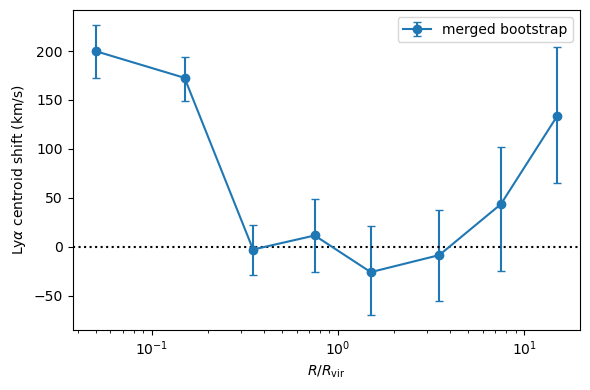

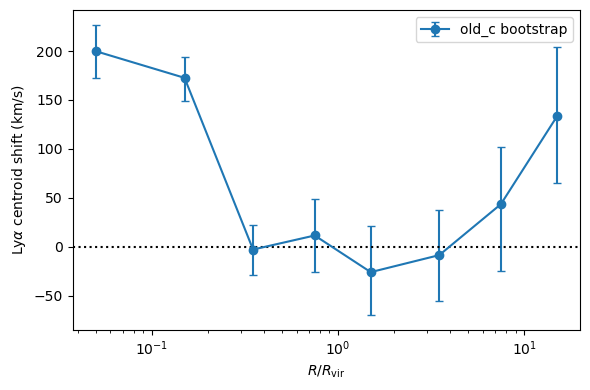

In [3]:
r_mid = 0.5*(np.array(stacks['r_edges'][:-1]) + np.array(stacks['r_edges'][1:]))
plt.figure(figsize=(6,4))
plt.errorbar(r_mid, merged['centroid_v_med'],
             yerr=[merged['centroid_v_med']-merged['centroid_v_lo'],
                   merged['centroid_v_hi']-merged['centroid_v_med']],
             marker='o', capsize=3, label='merged bootstrap')
plt.axhline(0, ls=':', c='k')
plt.xscale('log'); plt.xlabel(r'$R/R_{\rm vir}$')
plt.ylabel(r'Ly$\alpha$ centroid shift (km/s)'); plt.legend(); plt.tight_layout()

r_mid = 0.5*(np.array(stacks['r_edges'][:-1]) + np.array(stacks['r_edges'][1:]))
plt.figure(figsize=(6,4))
plt.errorbar(r_mid, old_c['centroid_v_med'],
             yerr=[old_c['centroid_v_med']-old_c['centroid_v_lo'],
                   old_c['centroid_v_hi']-old_c['centroid_v_med']],
             marker='o', capsize=3, label='old_c bootstrap')
plt.axhline(0, ls=':', c='k')
plt.xscale('log'); plt.xlabel(r'$R/R_{\rm vir}$')
plt.ylabel(r'Ly$\alpha$ centroid shift (km/s)'); plt.legend(); plt.tight_layout()

## 2. Background smoother — vectorized vs current, on a real background

Uses a real background spectrum from the `BACKGROUND` HDU of your galaxy FITS.
Agreement is measured **relative to the background noise**; anything ≪ 1 is fine.

current 200A adaptive : 66.533 ms/spectrum
interp-then-20A      :  0.225 ms/spectrum   (296x faster)
z=3.391  observed Lya = 5337.9 A  |  masked 5328-5348 A


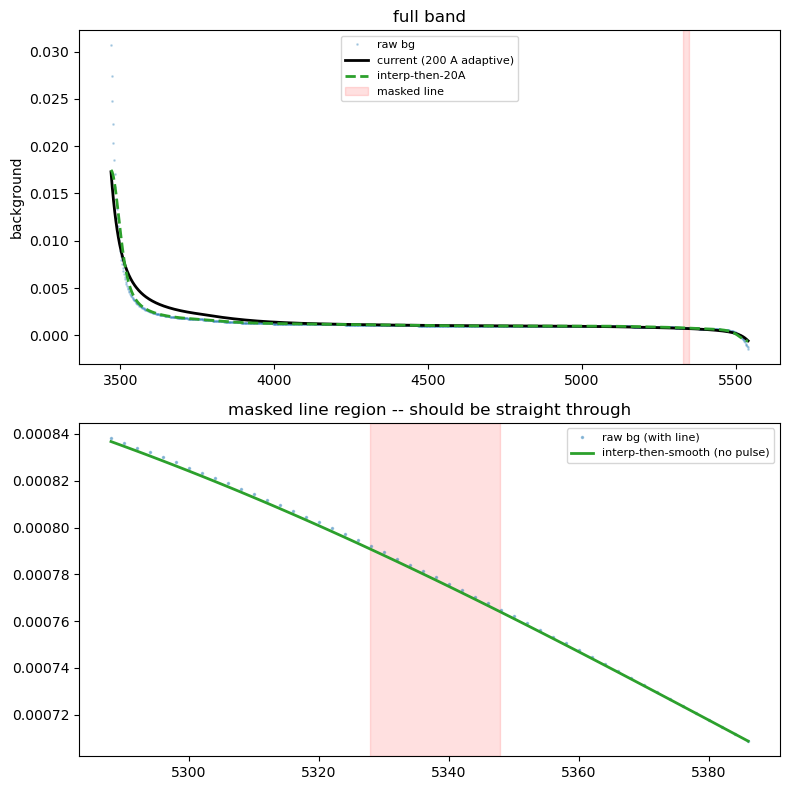

In [13]:
# ---- CELL: interp-then-smooth background smoother (test + time on real bg) ----
import numpy as np, matplotlib.pyplot as plt, time
from scipy.ndimage import gaussian_filter1d
from utils_lya_halo import read_galaxy_fits
from utils_lya_halo.smoothing import smooth_spectrum_nan_safe_adaptive  # current, for comparison

def smooth_interp_then_gauss(flux, wave, z, lya_rest=1215.67, sigma_A=25.0,
                             mask_halfwidth_A=20.0, mode='reflect'):
    """
    Background smoother: mask the Lya line, LINEARLY interpolate across the gap,
    THEN run a single uniform Gaussian smooth over the (now gap-free) spectrum.

    Order matters: interpolating first physically removes the line from the data,
    so the smoother sees no gap and no line -- no division-fill bowing, no pulse
    artifact, no wing-anchoring. A plain fixed-width gaussian_filter1d then does
    the smoothing (fast, C-level, no NaN-safe division needed).

      flux, wave       : (nwave,) background for one galaxy
      z                : that galaxy's systemic redshift (MOSDEF)
      sigma_A          : uniform smoothing width (A)
      mask_halfwidth_A : half-width of the masked line region (A); interpolated across
    Returns the smoothed background, same shape.
    """
    flux = np.asarray(flux, float).copy()
    wave = np.asarray(getattr(wave, 'value', wave), float)
    lam = lya_rest * (1 + z)
    line = np.abs(wave - lam) <= mask_halfwidth_A
    good = np.isfinite(flux)
    fill = good & ~line                                   # clean anchor pixels
    if fill.sum() >= 2:                                   # linear-interp the gap (+ any NaNs)
        flux[~fill] = np.interp(wave[~fill], wave[fill], flux[fill])
    dw = np.nanmedian(np.diff(wave)); sig_pix = sigma_A / dw
    return gaussian_filter1d(flux, sig_pix, mode=mode)

# ---- run on a real galaxy background ----
i = 38
w  = np.asarray(prod.wave, float)
bg = np.asarray(prod.background[i], float)
z  = float(prod.catalog[cfg.z_col][i])
SIGMA_A, MASK_HW_A = 20.0, 10.0
lam_line = cfg.LYA_REST * (1 + z)

new = smooth_interp_then_gauss(bg, w, z, lya_rest=cfg.LYA_REST,
                               sigma_A=SIGMA_A, mask_halfwidth_A=MASK_HW_A)
old = smooth_spectrum_nan_safe_adaptive(bg, w, sigma_A=200, edge_sigma_A=20, edge_width_A=300)

# ---- timing (median over N repeats = the per-exposure workload) ----
N = 200
def _t(fn):
    ts = [ (lambda: (time.perf_counter(), fn(), time.perf_counter()))() for _ in range(N) ]
    return np.median([b - a for a, _, b in ts])
t_old = _t(lambda: smooth_spectrum_nan_safe_adaptive(bg, w, sigma_A=200, edge_sigma_A=20, edge_width_A=300))
t_new = _t(lambda: smooth_interp_then_gauss(bg, w, z, sigma_A=SIGMA_A, mask_halfwidth_A=MASK_HW_A))
print(f"current 200A adaptive : {1e3*t_old:6.3f} ms/spectrum")
print(f"interp-then-{SIGMA_A:g}A      : {1e3*t_new:6.3f} ms/spectrum   ({t_old/t_new:.0f}x faster)")

# ---- plot: full band + masked-line zoom ----
fig, ax = plt.subplots(2, 1, figsize=(8, 8))
ax[0].plot(w, bg, '.', ms=2, alpha=.25, label='raw bg')
ax[0].plot(w, old, 'k',  lw=2, label='current (200 A adaptive)')
ax[0].plot(w, new, 'C2--', lw=2, label=f'interp-then-{SIGMA_A:g}A')
ax[0].axvspan(lam_line-MASK_HW_A, lam_line+MASK_HW_A, color='r', alpha=.12, label='masked line')
ax[0].legend(fontsize=8); ax[0].set_title('full band'); ax[0].set_ylabel('background')

m = np.abs(w - lam_line) < 5*MASK_HW_A
ax[1].plot(w[m], bg[m], '.', ms=3, alpha=.4, label='raw bg (with line)')
ax[1].plot(w[m], new[m], 'C2-', lw=2, label='interp-then-smooth (no pulse)')
ax[1].axvspan(lam_line-MASK_HW_A, lam_line+MASK_HW_A, color='r', alpha=.12)
ax[1].set_title('masked line region -- should be straight through'); ax[1].legend(fontsize=8)
plt.tight_layout()
print(f"z={z:.3f}  observed Lya = {lam_line:.1f} A  |  masked {lam_line-MASK_HW_A:.0f}-{lam_line+MASK_HW_A:.0f} A")

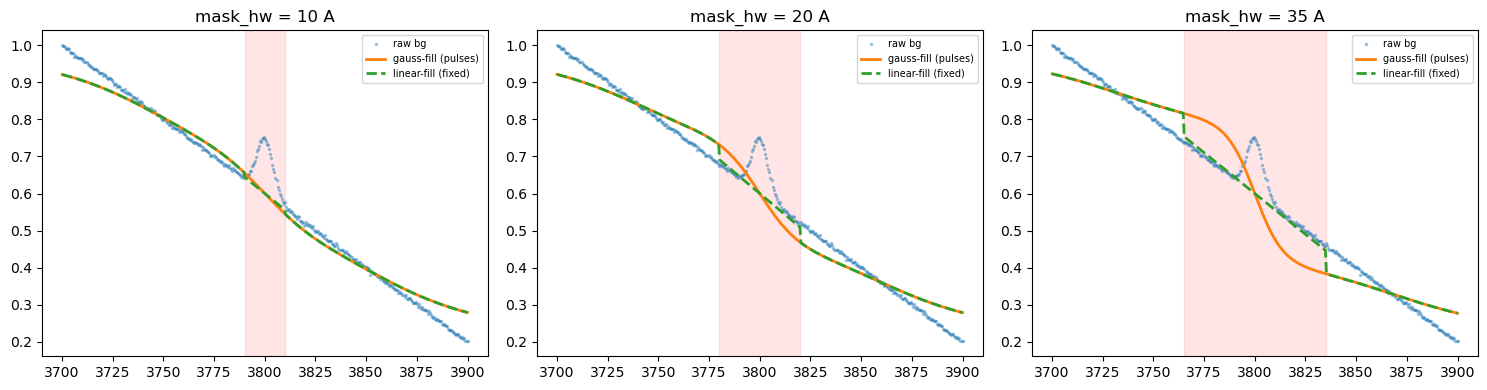

In [75]:
# ---- CELL: why the pulse appears, and two fixes ----
import numpy as np, matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def _nan_gauss(flux, wave, use, sigma_A, mode='constant'):
    dw = np.nanmedian(np.diff(wave)); sp = sigma_A/dw
    num = gaussian_filter1d(np.where(use, flux, 0.0), sp, mode=mode)
    den = gaussian_filter1d(use.astype(float),        sp, mode=mode)
    return np.divide(num, den, out=np.full_like(num, np.nan), where=den > 0)

def smooth_gaussfill(flux, wave, z, sigma_A=25, mask_hw=20, lya=1215.67):
    """Original approach: Gaussian fill bridges the gap (bows on a slope)."""
    use = np.isfinite(flux) & (np.abs(wave - lya*(1+z)) > mask_hw)
    return _nan_gauss(flux, wave, use, sigma_A)

def smooth_linfill(flux, wave, z, sigma_A=25, mask_hw=20, fit_pad=40, lya=1215.67):
    """Fix 2: smooth the UNmasked spectrum, then replace the masked gap with a
    LOCAL LINEAR fit to the clean continuum on either side (follows the slope)."""
    lam = lya*(1+z)
    line = np.abs(wave - lam) <= mask_hw
    use  = np.isfinite(flux) & ~line
    sm   = _nan_gauss(flux, wave, use, sigma_A)          # clean everywhere but the gap edges
    # fit a line to the smoothed continuum in a pad on each side of the mask
    side = use & (np.abs(wave - lam) <= mask_hw + fit_pad)
    if side.sum() >= 2:
        p = np.polyfit(wave[side], sm[side], 1)
        sm = sm.copy(); sm[line] = np.polyval(p, wave[line])
    return sm

# ---- demo on a sloped continuum with a real line (mimics your figure) ----
rng = np.random.default_rng(0)
w = np.linspace(3700, 3900, 400)
z = (3800/1215.67) - 1                          # put Lya at 3800
cont = 1.0 - 0.004*(w-3700)                     # steep local slope, like your zoom
line = 0.15*np.exp(-0.5*((w-1215.67*(1+z))/4)**2)
bg = cont + line + rng.normal(0, 0.003, w.size)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, hw in zip(axes, (10, 20, 35)):           # watch the pulse vs mask width
    ax.plot(w, bg, '.', ms=3, alpha=.35, label='raw bg')
    ax.plot(w, smooth_gaussfill(bg, w, z, 25, hw), 'C1-',  lw=2, label='gauss-fill (pulses)')
    ax.plot(w, smooth_linfill(bg,  w, z, 25, hw), 'C2--', lw=2, label='linear-fill (fixed)')
    ax.axvspan(1215.67*(1+z)-hw, 1215.67*(1+z)+hw, color='r', alpha=.1)
    ax.set_title(f'mask_hw = {hw} A'); ax.legend(fontsize=7)
plt.tight_layout()

## 3. `rest_delta` sweep — does the grid choice move the centroids?

Re-runs Stage 2+3 on your real data at several grids. Expect the centroid
profiles to agree within errors down to ~native sampling; finer grids just add
correlated pixels. (Uses a modest `n_bootstrap` for speed — raise for the paper.)

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

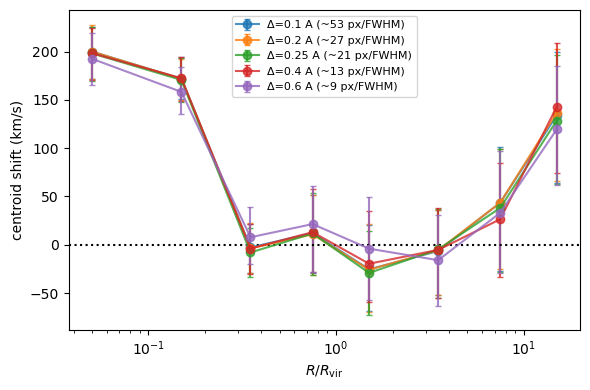

In [7]:
deltas = [0.1, 0.2, 0.25, 0.4, 0.6]
NB_sweep = 200
plt.figure(figsize=(6,4))
for d in deltas:
    c = replace(cfg, rest_delta=d, n_bootstrap=NB_sweep)
    st = run_stack(c, keep_cube=True, verbose=False)
    rs = run_measure(c, st)
    rm = 0.5*(np.array(st['r_edges'][:-1])+np.array(st['r_edges'][1:]))
    npix_fwhm = (2.355*np.hypot(1.5,1.7))/d
    plt.errorbar(rm, rs['centroid_v_med'],
                 yerr=[rs['centroid_v_med']-rs['centroid_v_lo'],
                       rs['centroid_v_hi']-rs['centroid_v_med']],
                 marker='o', capsize=2, alpha=.8,
                 label=f'Δ={d} A (~{npix_fwhm:.0f} px/FWHM)')
plt.axhline(0,ls=':',c='k'); plt.xscale('log'); plt.xlabel(r'$R/R_{\rm vir}$')
plt.ylabel('centroid shift (km/s)'); plt.legend(fontsize=8); plt.tight_layout()

## 4. `cont_bounds` — current vs line-safe sidebands, on real centroids

Same stacks, only the continuum sidebands change. If the centroid moves in the
inner bins (where a real continuum exists) but not the outer ones, that's the ISM
absorption in the sidebands biasing the current continuum.

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

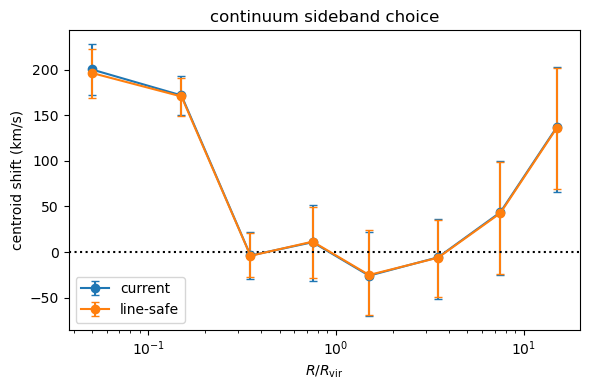

In [9]:
variants = {
    'current':   cfg.cont_bounds,
    'line-safe': ((1195,1205),(1225,1236)),   # avoids SiII/SiIII/NV
}
plt.figure(figsize=(6,4))
for name, cb in variants.items():
    c = replace(cfg, cont_bounds=cb, n_bootstrap=200)
    rs = run_measure(c, stacks)
    rm = 0.5*(np.array(stacks['r_edges'][:-1])+np.array(stacks['r_edges'][1:]))
    plt.errorbar(rm, rs['centroid_v_med'],
                 yerr=[rs['centroid_v_med']-rs['centroid_v_lo'],
                       rs['centroid_v_hi']-rs['centroid_v_med']],
                 marker='o', capsize=3, label=name)
plt.axhline(0,ls=':',c='k'); plt.xscale('log'); plt.xlabel(r'$R/R_{\rm vir}$')
plt.ylabel('centroid shift (km/s)'); plt.legend(); plt.title('continuum sideband choice')
plt.tight_layout()

## 5. SHMR / Rvir — how much does the relation move your bins?

Applies Moster+2013 (your current) and Moster+2018 to your **real** catalog
masses+redshifts, plus the ±0.2 dex scatter band. If the relation-to-relation
shift sits inside the scatter band, the SHMR choice is a sub-dominant systematic.

median Rvir  Moster13=80.6 kpc  Moster18=70.3 kpc  Δ=-12.8%
±0.2 dex scatter band = +17% / -14%


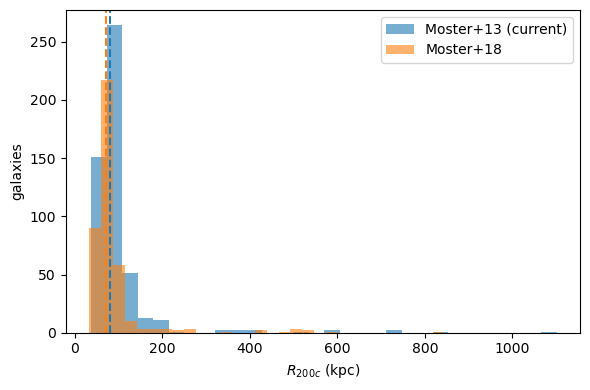

In [23]:
from utils_lya_halo.virial import R200c_from_M200c, mhalo_from_mstar_moster13
from scipy.optimize import brentq

def moster18_mstar_from_mhalo(Mh, z):
    zt=z/(1+z); M1=10**(11.339+0.692*zt); N=0.0342-0.0286*zt
    beta=1.799-1.361*zt; gamma=0.966
    return (2*N/((Mh/M1)**(-beta)+(Mh/M1)**gamma))*Mh

def mhalo_from_mstar_moster13_safe(Mstar, z, lo=8.0, hi=16.0, n=300):
    def f(logMh):
        return np.log10(moster13_mstar_from_mhalo(10**logMh, z)) - np.log10(Mstar)
    grid = np.linspace(lo, hi, n)
    vals = np.array([f(g) for g in grid])
    k = np.where(np.diff(np.sign(vals)) != 0)[0]   # first sign change
    if k.size == 0:
        return np.nan                              # M* outside the relation's range
    return 10**brentq(f, grid[k[0]], grid[k[0]+1])

# use it exactly like before:
logM = np.asarray(prod.catalog[cfg.mass_col], float)
zg   = np.asarray(prod.catalog[cfg.z_col], float)
ok = np.isfinite(logM) & np.isfinite(zg) & (zg > 0)
logM, zg = logM[ok], zg[ok]

rv13 = np.array([R200c_from_M200c(mhalo_from_mstar_moster13_safe(10**m, z), z)
                 for m, z in zip(logM, zg)])

rv18 = np.array([R200c_from_M200c(mhalo_from_mstar(moster18_mstar_from_mhalo,10**m,z), z) for m,z in zip(logM,zg)])
print(f"median Rvir  Moster13={np.nanmedian(rv13):.1f} kpc  "
      f"Moster18={np.nanmedian(rv18):.1f} kpc  "
      f"Δ={100*(np.nanmedian(rv18)-np.nanmedian(rv13))/np.nanmedian(rv13):+.1f}%")
print(f"±0.2 dex scatter band = {100*((10**0.2)**(1/3)-1):+.0f}% / {100*((10**-0.2)**(1/3)-1):+.0f}%")

plt.figure(figsize=(6,4))
plt.hist(rv13,bins=30,alpha=.6,label='Moster+13 (current)')
plt.hist(rv18,bins=30,alpha=.6,label='Moster+18')
plt.axvline(np.nanmedian(rv13),c='C0',ls='--'); plt.axvline(np.nanmedian(rv18),c='C1',ls='--')
plt.xlabel(r'$R_{200c}$ (kpc)'); plt.ylabel('galaxies'); plt.legend(); plt.tight_layout()

z=2.0: M18 invertible up to logM* ~ 10.4
z=2.3: M18 invertible up to logM* ~ 10.4
z=2.7: M18 invertible up to logM* ~ 10.2
z=3.0: M18 invertible up to logM* ~ 10.2


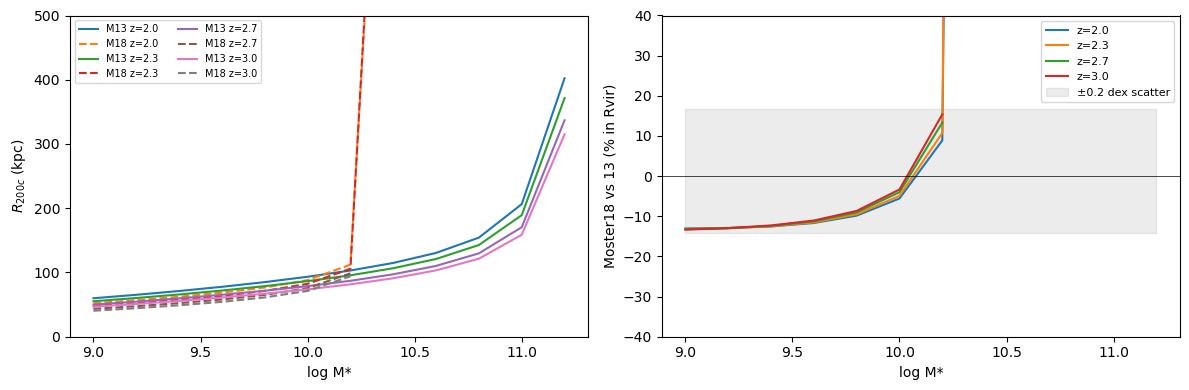

In [33]:
# ---- CELL: Moster13 vs Moster18, inversion guarded against the knee ----
import numpy as np, matplotlib.pyplot as plt
from scipy.optimize import brentq
from utils_lya_halo.virial import moster13_mstar_from_mhalo, R200c_from_M200c

def moster18_mstar_from_mhalo(Mh, z):
    # NOTE: coefficients are APPROXIMATE (not paper-verified). Do not use for
    # the paper until checked against Moster+2018 Table 1.
    zt = z/(1+z)
    M1   = 10**(11.339 + 0.692*zt)
    N    = 0.0342 - 0.0286*zt
    beta = 1.799 - 1.361*zt
    gamma= 0.966
    return (2*N/((Mh/M1)**(-beta) + (Mh/M1)**gamma)) * Mh

def invert_monotonic(fn, Mstar, z, lo=8, hi=15.5, n=400):
    """Invert only over the range where M*(Mh) is monotonically increasing,
    so a turnover near the knee can't send us to a spurious high-mass branch."""
    g = np.linspace(lo, hi, n)
    ms = np.array([np.log10(fn(10**x, z)) for x in g])
    # keep the rising branch only (cumulative max mask)
    rising = np.concatenate([[True], np.diff(ms) > 0])
    g, ms = g[rising], ms[rising]
    target = np.log10(Mstar)
    if target < ms.min() or target > ms.max():
        return np.nan                       # outside the invertible range
    return 10**np.interp(target, ms, g)     # monotone -> safe interpolation

def rvir(fn, logM, z, invert):
    Mh = invert(fn, 10**logM, z)
    return R200c_from_M200c(Mh, z) if np.isfinite(Mh) else np.nan

masses = np.linspace(9.0, 11.2, 12)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
for z in (2.0, 2.3, 2.7, 3.0):
    r13 = np.array([rvir(moster13_mstar_from_mhalo, m, z, invert_monotonic) for m in masses])
    r18 = np.array([rvir(moster18_mstar_from_mhalo, m, z, invert_monotonic) for m in masses])
    a1.plot(masses, r13, '-',  label=f'M13 z={z}')
    a1.plot(masses, r18, '--', label=f'M18 z={z}')
    with np.errstate(invalid='ignore'):
        a2.plot(masses, 100*(r18-r13)/r13, label=f'z={z}')
a1.set_xlabel('log M*'); a1.set_ylabel(r'$R_{200c}$ (kpc)')
a1.set_ylim(0, 500); a1.legend(fontsize=7, ncol=2)          # clip the y-axis so the valid range is readable
a2.axhline(0, c='k', lw=.5)
a2.fill_between(masses, 100*((10**-0.2)**(1/3)-1), 100*((10**0.2)**(1/3)-1),
                alpha=.15, color='gray', label='±0.2 dex scatter')
a2.set_xlabel('log M*'); a2.set_ylabel('Moster18 vs 13 (% in Rvir)')
a2.set_ylim(-40, 40); a2.legend(fontsize=8)                  # zoom to the physically sensible band
plt.tight_layout()

# where is M18 even invertible? (NaNs = past the knee for these coeffs)
for z in (2.0, 2.3, 2.7, 3.0):
    top = max([m for m in masses if np.isfinite(rvir(moster18_mstar_from_mhalo, m, z, invert_monotonic))],
              default=np.nan)
    print(f"z={z}: M18 invertible up to logM* ~ {top:.1f}")

In [37]:
z_sel = 2.3
r13 = np.array([rvir(moster13_mstar_from_mhalo, m, z_sel, invert_monotonic) for m in masses])
r18 = np.array([rvir(moster18_mstar_from_mhalo, m, z_sel, invert_monotonic) for m in masses])

print(z_sel, masses, r13, r18)

2.3 [ 9.   9.2  9.4  9.6  9.8 10.  10.2 10.4 10.6 10.8 11.  11.2] [ 55.25496371  60.26704841  65.78858534  71.90910796  78.75912045
  86.54331009  95.61015329 106.62019412 121.01056855 142.77185459
 189.20515561 371.42176356] [  47.97446253   52.44713117   57.56350954   63.62307301   71.26983707
   82.29618923  105.88097333 1305.43173898           nan           nan
           nan           nan]


## 6. Forward-model an intrinsic width on a real stacked bin

Instead of deconvolving (ill-posed at low S/N), fit an intrinsic Gaussian
**convolved with your LSF** directly to a real stacked bin. Set `lsf_sigma_A`
to your measured effective LSF (instrument ⊕ z-error).

intrinsic sigma = 1.67 ± 0.15 A   (mu = 1216.37 A -> +173 km/s)


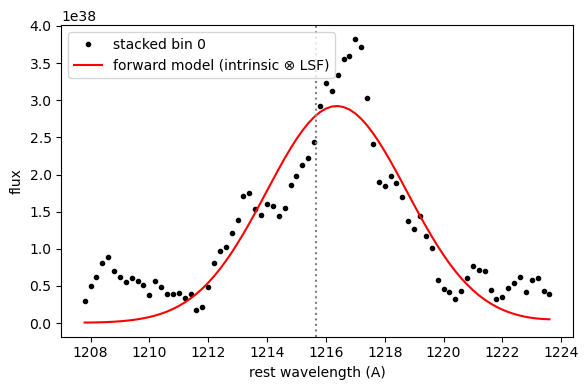

In [12]:
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d

rb = 0                                  # which radial bin
lsf_sigma_A = 1.7                       # <-- your measured effective LSF sigma (A)
delta = float(cfg.rest_delta)
stack = stacks['stacks'][cfg.measure_stack_method]['flux'][rb]
w = wave
def forward(x, amp, mu, sig_int):
    return gaussian_filter1d(amp*np.exp(-0.5*((x-mu)/sig_int)**2), lsf_sigma_A/delta)
m = (w > cfg.LYA_REST-8) & (w < cfg.LYA_REST+8)
p, cov = curve_fit(forward, w[m], stack[m],
                   p0=[np.nanmax(stack[m]), cfg.LYA_REST, 1.0], maxfev=5000)
print(f"intrinsic sigma = {abs(p[2]):.2f} ± {np.sqrt(cov[2,2]):.2f} A   "
      f"(mu = {p[1]:.2f} A -> {(p[1]-cfg.LYA_REST)/cfg.LYA_REST*3e5:+.0f} km/s)")

plt.figure(figsize=(6,4))
plt.plot(w[m], stack[m], 'k.', label=f'stacked bin {rb}')
plt.plot(w[m], forward(w[m], *p), 'r-', label='forward model (intrinsic ⊗ LSF)')
plt.axvline(cfg.LYA_REST, ls=':', c='gray'); plt.xlabel('rest wavelength (A)')
plt.ylabel('flux'); plt.legend(); plt.tight_layout()

---
### Notes
- Cells 1, 3–6 all reuse the Cell-0 `stacks`/`cube`/`prod`, so run Cell 0 first.
- For paper-grade numbers, restore `n_bootstrap=cfg.n_bootstrap` (the sweeps use
  small values only to keep the notebook snappy).
- Cell 1 proves the merged bootstrap is *numerically identical* to your current
  two loops (Δ ≈ 0), so adopting it changes speed only, not results.